# Limpieza y preparación de datos

En este notebook se realiza la limpieza del dataset de potabilidad del agua.
- Nulos
- Outliers
- No existen duplicados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.shape


(3276, 10)

In [5]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
# Crear una copia
df_limpio = df.copy()

In [9]:
columnas_con_nulos = ['ph', 'Sulfate', 'Trihalomethanes']

df_limpio[columnas_con_nulos].median()

ph                   7.036752
Sulfate            333.073546
Trihalomethanes     66.622485
dtype: float64

In [10]:
# Analizar nulos por fila
columnas_con_nulos = ['ph', 'Sulfate', 'Trihalomethanes']

nulos_por_fila = df[columnas_con_nulos].isnull().sum(axis=1)

nulos_por_fila.value_counts().sort_index()

0    2011
1    1105
2     151
3       9
Name: count, dtype: int64

- Se eliminaran las filas con 3 valores nulos
- Se tomara en cuenta el peso de las variables para eliminar unas cuantas filas con dos nulos

In [11]:
filas_con_2_nulos = df[nulos_por_fila == 2]

filas_con_2_nulos[columnas_con_nulos].isnull().value_counts()

ph     Sulfate  Trihalomethanes
True   True     False              103
False  True     True                31
True   False    True                17
Name: count, dtype: int64

- Debido a que el ph es un valor critico para determinar la potabilidad, se decide eliminar las filas que tienen nulos en esta columna.
- En el caso de las demas, se imputara con la mediana para no perder muchos datos

In [12]:
# Eliminar filas con 2 o más nulos
df_limpio = df_limpio.dropna(
    subset=columnas_con_nulos,
    thresh=1
)

In [13]:
# Eliminar filas con dos nulos y uno de ellos es 'ph'
nulos_por_fila = df_limpio[columnas_con_nulos].isnull().sum(axis=1)

condicion_eliminar_ph = (
    (nulos_por_fila == 2) &
    (df_limpio['ph'].isnull())
)

In [14]:
df_limpio = df_limpio.drop(index=df_limpio[condicion_eliminar_ph].index)

In [15]:
df_limpio.shape

(3147, 10)

In [16]:
nulos_por_fila_limpio = df_limpio[columnas_con_nulos].isnull().sum(axis=1)

nulos_por_fila_limpio.value_counts().sort_index()

0    2011
1    1105
2      31
Name: count, dtype: int64

In [17]:
df_limpio.isnull().sum()


ph                 362
Hardness             0
Solids               0
Chloramines          0
Sulfate            669
Conductivity         0
Organic_carbon       0
Trihalomethanes    136
Turbidity            0
Potability           0
dtype: int64

- Se procedera a llenar los nulos faltantes con la mediana de cada columnas_con_nulos
- Se recurre a la mediana ya que anteriormente se identificó outliers en las variables

In [18]:
# Rellenar nulos con la mediana
columnas_con_nulos = ['ph', 'Sulfate', 'Trihalomethanes']

medianas_imputacion = df_limpio[columnas_con_nulos].median()
medianas_imputacion

ph                   7.036752
Sulfate            333.073455
Trihalomethanes     66.608891
dtype: float64

In [19]:
for columna in columnas_con_nulos:
    df_limpio[columna] = df_limpio[columna].fillna(medianas_imputacion[columna])

In [20]:
df_limpio.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

- Se completó el tratamiento de nulos 
- Se elimino los datos de muestras con 2 y 3 nulos que tenian la variable 'ph' como nula ya que esta es importante
- Para evitar perder demasiados datos se rellenaron los nulos restantes con la mediana de cada columna 

In [21]:
df.shape
df_limpio.shape

(3147, 10)

In [22]:
df_limpio.duplicated().sum()

np.int64(0)

No se encontraron registros duplicados en el dataset limpio.

## Revisión de valores atípicos

Además de los valores nulos, se revisan posibles valores atípicos en las variables independientes.  

En este proyecto no se eliminarán automáticamente los outliers, ya que pueden representar mediciones reales de calidad del agua. Eliminarlos sin una justificación técnica podría reducir información importante para el análisis y el modelo.

In [23]:
variables_independientes = [
    'ph',
    'Hardness',
    'Solids',
    'Chloramines',
    'Sulfate',
    'Conductivity',
    'Organic_carbon',
    'Trihalomethanes',
    'Turbidity'
]

outliers = {}

for columna in variables_independientes:
    media = df_limpio[columna].mean()
    desviacion = df_limpio[columna].std()

    limite_inferior = media - 3 * desviacion
    limite_superior = media + 3 * desviacion

    cantidad_outliers = df_limpio[
        (df_limpio[columna] < limite_inferior) |
        (df_limpio[columna] > limite_superior)
    ][columna].count()

    outliers[columna] = cantidad_outliers

tabla_outliers = pd.DataFrame.from_dict(
    outliers,
    orient='index',
    columns=['Cantidad de posibles outliers']
)

tabla_outliers.sort_values(by='Cantidad de posibles outliers', ascending=False)

,Cantidad de posibles outliers
Sulfate,31
ph,21
Solids,20
Chloramines,20
Hardness,18
Trihalomethanes,16
Turbidity,8
Conductivity,6
Organic_carbon,4


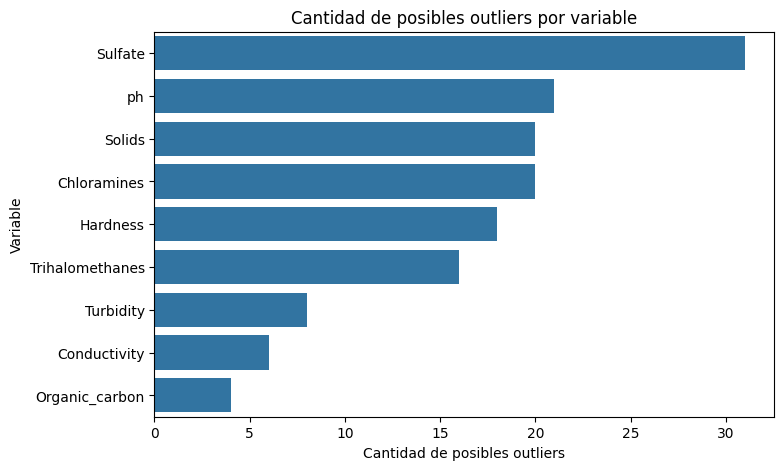

In [24]:
tabla_outliers_ordenada = tabla_outliers.sort_values(
    by='Cantidad de posibles outliers',
    ascending=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=tabla_outliers_ordenada['Cantidad de posibles outliers'],
    y=tabla_outliers_ordenada.index
)

plt.title('Cantidad de posibles outliers por variable')
plt.xlabel('Cantidad de posibles outliers')
plt.ylabel('Variable')

plt.show()

In [25]:
registros_outliers = []

for columna in variables_independientes:
    media = df_limpio[columna].mean()
    desviacion = df_limpio[columna].std()

    limite_inferior = media - 3 * desviacion
    limite_superior = media + 3 * desviacion

    outliers_columna = df_limpio[
        (df_limpio[columna] < limite_inferior) |
        (df_limpio[columna] > limite_superior)
    ]

    for indice, fila in outliers_columna.iterrows():
        registros_outliers.append({
            'indice_fila': indice,
            'variable': columna,
            'valor': fila[columna],
            'limite_inferior': limite_inferior,
            'limite_superior': limite_superior,
            'Potability': fila['Potability']
        })

df_outliers = pd.DataFrame(registros_outliers)

df_outliers

,indice_fila,variable,valor,limite_inferior,limite_superior,Potability
0,80,ph,1.844538,2.576159,11.575298,0.0
1,263,ph,13.175402,2.576159,11.575298,1.0
2,692,ph,1.757037,2.576159,11.575298,1.0
3,726,ph,0.227499,2.576159,11.575298,1.0
4,783,ph,11.898078,2.576159,11.575298,1.0
...,...,...,...,...,...,...
139,1073,Turbidity,6.389161,1.619234,6.317282,1.0
140,1290,Turbidity,1.496101,1.619234,6.317282,0.0
141,1892,Turbidity,1.492207,1.619234,6.317282,1.0
142,2921,Turbidity,6.494749,1.619234,6.317282,0.0


In [26]:
df_outliers.sort_values(by=['variable', 'valor'])

,indice_fila,variable,valor,limite_inferior,limite_superior,Potability
68,2302,Chloramines,0.352000,2.362602,11.880525,1.0
61,285,Chloramines,0.530351,2.362602,11.880525,1.0
70,2350,Chloramines,1.390871,2.362602,11.880525,1.0
66,509,Chloramines,1.683993,2.362602,11.880525,0.0
72,2401,Chloramines,1.920271,2.362602,11.880525,1.0
...,...,...,...,...,...,...
6,1303,ph,12.246928,2.576159,11.575298,0.0
1,263,ph,13.175402,2.576159,11.575298,1.0
14,2895,ph,13.349889,2.576159,11.575298,0.0
13,2868,ph,13.541240,2.576159,11.575298,0.0


- Se identificaron posibles incoherencias en los datos con respecto a sus resultados de potabilidad, lo que podría indicar fuertes outliers o errores en la medición. 

In [27]:
# Revision de incoherencias entre variables
# pH físicamente imposible
df_limpio[(df_limpio['ph'] < 0) | (df_limpio['ph'] > 14)]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability


In [29]:
inconsistencias_fuertes = pd.DataFrame({
    'criterio': [
        'ph < 0 o ph > 14',
        'Hardness < 0',
        'Solids < 0',
        'Chloramines < 0',
        'Sulfate < 0',
        'Conductivity < 0',
        'Organic_carbon < 0',
        'Trihalomethanes < 0',
        'Turbidity < 0'
    ],
    'cantidad': [
        len(df_limpio[(df_limpio['ph'] < 0) | (df_limpio['ph'] > 14)]),
        len(df_limpio[df_limpio['Hardness'] < 0]),
        len(df_limpio[df_limpio['Solids'] < 0]),
        len(df_limpio[df_limpio['Chloramines'] < 0]),
        len(df_limpio[df_limpio['Sulfate'] < 0]),
        len(df_limpio[df_limpio['Conductivity'] < 0]),
        len(df_limpio[df_limpio['Organic_carbon'] < 0]),
        len(df_limpio[df_limpio['Trihalomethanes'] < 0]),
        len(df_limpio[df_limpio['Turbidity'] < 0])
    ]
})

inconsistencias_fuertes

,criterio,cantidad
0,ph < 0 o ph > 14,0
1,Hardness < 0,0
2,Solids < 0,0
3,Chloramines < 0,0
4,Sulfate < 0,0
5,Conductivity < 0,0
6,Organic_carbon < 0,0
7,Trihalomethanes < 0,0
8,Turbidity < 0,0


- No existen valores físicamente imposibles en las variables del dataset.

In [30]:
variables_independientes = [
    'ph',
    'Hardness',
    'Solids',
    'Chloramines',
    'Sulfate',
    'Conductivity',
    'Organic_carbon',
    'Trihalomethanes',
    'Turbidity'
]

potables_raros = []

for columna in variables_independientes:
    media = df_limpio[columna].mean()
    desviacion = df_limpio[columna].std()

    limite_inferior = media - 3 * desviacion
    limite_superior = media + 3 * desviacion

    casos = df_limpio[
        (df_limpio['Potability'] == 1) &
        (
            (df_limpio[columna] < limite_inferior) |
            (df_limpio[columna] > limite_superior)
        )
    ]

    for indice, fila in casos.iterrows():
        potables_raros.append({
            'indice_fila': indice,
            'variable': columna,
            'valor': fila[columna],
            'limite_inferior': limite_inferior,
            'limite_superior': limite_superior
        })

df_potables_raros = pd.DataFrame(potables_raros)

df_potables_raros

,indice_fila,variable,valor,limite_inferior,limite_superior
0,263,ph,13.175402,2.576159,11.575298
1,692,ph,1.757037,2.576159,11.575298
2,726,ph,0.227499,2.576159,11.575298
3,783,ph,11.898078,2.576159,11.575298
4,810,ph,0.989912,2.576159,11.575298
...,...,...,...,...,...
78,2376,Trihalomethanes,124.000000,19.000951,113.809964
79,3184,Trihalomethanes,114.034946,19.000951,113.809964
80,382,Turbidity,6.494249,1.619234,6.317282
81,1073,Turbidity,6.389161,1.619234,6.317282


In [31]:
# Cantidad de casos por variable
df_potables_raros['variable'].value_counts()

variable
Sulfate            21
Hardness           15
Chloramines        15
Solids             12
Trihalomethanes     8
ph                  6
Turbidity           3
Conductivity        2
Organic_carbon      1
Name: count, dtype: int64

In [32]:
indices_potables_raros = df_potables_raros['indice_fila'].unique()

df_limpio.loc[indices_potables_raros]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
263,13.175402,47.432000,19237.949676,8.907020,375.147315,500.245952,12.083896,66.608891,4.106924,1
692,1.757037,147.581831,41538.242730,7.728177,376.012933,428.444823,10.828696,65.005840,2.967554,1
726,0.227499,152.530111,39028.599340,3.462492,283.693782,443.029232,13.201943,62.322711,3.545741,1
783,11.898078,228.132673,8296.550611,9.899637,346.649750,500.169210,15.486862,63.529460,3.024968,1
810,0.989912,133.216942,16922.853899,9.293289,444.375731,322.291191,10.430076,43.578466,5.160604,1
...,...,...,...,...,...,...,...,...,...,...
2376,7.899452,210.734124,15896.365937,6.907203,319.886957,448.666423,18.169921,124.000000,2.853767,1
3184,8.285072,151.573778,14402.726696,9.050080,303.081838,322.521815,13.652653,114.034946,4.274661,1
382,5.772718,213.363545,26124.931415,8.630719,273.279448,465.559286,8.006208,59.964334,6.494249,1
1073,7.203439,168.445358,22826.484697,6.283250,271.892045,437.370863,16.410654,64.505923,6.389161,1


- Se debe identificar las muestras con muchos valores raros

In [33]:
conteo_raros_por_fila = df_potables_raros['indice_fila'].value_counts()

conteo_raros_por_fila

indice_fila
263     2
810     2
1186    2
1554    2
272     2
       ..
2376    1
3184    1
382     1
1073    1
1892    1
Name: count, Length: 76, dtype: int64

In [34]:
indices_muy_raros = conteo_raros_por_fila[conteo_raros_por_fila >= 2].index

df_limpio.loc[indices_muy_raros]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
indice_fila,,,,,,,,,,
263,13.175402,47.432000,19237.949676,8.907020,375.147315,500.245952,12.083896,66.608891,4.106924,1
810,0.989912,133.216942,16922.853899,9.293289,444.375731,322.291191,10.430076,43.578466,5.160604,1
1186,9.484703,122.906991,56351.396304,4.219711,219.553437,480.848063,13.533433,41.731219,4.132274,1
1554,8.942046,215.673786,56488.672413,3.231438,129.000000,541.915468,9.313771,70.828374,4.354288,1
272,6.512737,229.263861,22475.046873,12.580026,192.033592,479.501279,9.983462,66.668576,4.612964,1
275,5.324942,280.089655,35344.658047,13.043806,180.206746,392.421496,10.504820,55.084668,4.427138,1
351,8.848586,188.919983,32033.332019,13.127000,182.397370,479.791975,12.070444,77.671337,4.014682,1


Se eliminaron únicamente dos muestras etiquetadas como potables que presentaban valores de pH extremadamente incompatibles con agua de consumo (`ph = 13.17` y `ph = 0.99`). 

Estas muestras se consideran inconsistencias fuertes entre las variables fisicoquímicas y la etiqueta de potabilidad. Las demás muestras con valores extremos se conservaron, ya que no presentan una contradicción tan clara o podrían representar variabilidad real del dataset.

In [35]:
indices_eliminar = [263, 810]

df_limpio = df_limpio.drop(index=indices_eliminar)

## Conclusiones

In [36]:
df_limpio.shape

(3145, 10)

In [37]:
df_limpio.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Después del tratamiento aplicado, se verifica que el dataset limpio ya no contiene valores nulos.

In [38]:
df_limpio.duplicated().sum()

np.int64(0)

Se verifica nuevamente la existencia de registros duplicados. El resultado indica que no existen filas repetidas en el dataset limpio.

In [39]:
print("Dataset original:", df.shape)
print("Dataset limpio:", df_limpio.shape)

Dataset original: (3276, 10)
Dataset limpio: (3145, 10)


El dataset original contenía 3276 registros. Luego del proceso de limpieza, el dataset final conserva 3145 registros. La reducción se debe a la eliminación de muestras con alta incertidumbre por valores faltantes y dos inconsistencias fuertes relacionadas con valores extremos de pH en muestras etiquetadas como potables.

In [40]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 3145 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3145 non-null   float64
 1   Hardness         3145 non-null   float64
 2   Solids           3145 non-null   float64
 3   Chloramines      3145 non-null   float64
 4   Sulfate          3145 non-null   float64
 5   Conductivity     3145 non-null   float64
 6   Organic_carbon   3145 non-null   float64
 7   Trihalomethanes  3145 non-null   float64
 8   Turbidity        3145 non-null   float64
 9   Potability       3145 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 270.3 KB


Se verifica que las variables mantengan tipos de datos numéricos adecuados. La variable `Potability` se conserva como entero, ya que representa una clasificación binaria.

In [41]:
df_limpio.to_csv("water_potability_clean.csv", index=False)

El dataset limpio se guarda en un nuevo archivo llamado `water_potability_clean.csv`, que será utilizado en la siguiente etapa del proyecto.

- Se identificaron valores nulos en `ph`, `Sulfate` y `Trihalomethanes`.
- Se eliminaron las filas con tres valores nulos y aquellas con dos valores nulos donde faltaba `ph`.
- Los valores nulos restantes fueron imputados con la mediana de cada variable.
- Se revisaron muestras potables con valores extremos.
- Se eliminaron únicamente dos muestras con valores de pH extremadamente incompatibles con la etiqueta de agua potable.
- No se encontraron registros duplicados.
- El dataset limpio quedó listo para la etapa de feature engineering.